<a href="https://colab.research.google.com/github/adamszmatula/Malaria-Detection/blob/main/Malaria_Detection_Best_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Importing the libraries necessary to load and resize the images
import zipfile
import os
from PIL import Image

# Importing the common and necessary libraries for data science
# Pandas for manipulating dataframes
import pandas as pd
# Numpy for manipulating arrays
import numpy as np
# Matlplotlib for data visualisation
import matplotlib.pyplot as plt
# Seaborn for statistical data visualisation
import seaborn as sns
# Random for generating random numbers
import random

# Scikit-learn for machine learning
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, classification_report
# Library for splitting the data
from sklearn.model_selection import train_test_split

# Tensorflow for machine learning and building neural networks
import tensorflow as tf
# Tensorflow.keras API for deep learning
from tensorflow.keras import backend # backend for clearing and reseting the session
from tensorflow.keras.models import Sequential, load_model # Sequential for building linear stacks of layers
from tensorflow.keras.utils import to_categorical # to_categorical to convert arrays and matrices to categorical data
# Layers and optimizers for importing all the different layers and optimizers
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # to stop training when it stops improving and to save the best model

# ImageDataGenerator for Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# TensorFlow.keras VGG16 model for Transfer Learning
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

# OpenCV for image processing operations
import cv2

# Dectivate clipping logs from matplotlib
import logging
logging.getLogger('matplotlib.image').setLevel(logging.ERROR)

# The below code can be used to ignore the warnings that may occur due to deprecations
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Storing the path of the .zip file on my personal Google Drive
path = '/content/drive/MyDrive/Capstone Project/cell_images.zip'

# Unpacking the dataset to the Google Colab local storage for more convenient I/O operation and handling
with zipfile.ZipFile(path, 'r') as zip_ref:
  zip_ref.extractall('/content/')

In [5]:
# Storing the train dataset path into a separate variable
train_path = ('/content/cell_images/train/')

# Creating lists to store the images and labels after extraction
train_images = []
train_labels = []

# Looping through the entire dataset to open the images, extract and store them with the labels in the corresponding lists
for category, label in [('uninfected', 0), ('parasitized', 1)]:
    category_folder_path = os.path.join(train_path, category)
    for file in os.listdir(category_folder_path):
      try:
        img_path = os.path.join(category_folder_path, file)
        img = Image.open(img_path)
        img = img.resize((64, 64))
        img = np.array(img)
        train_images.append(img)
        train_labels.append(label)
      except Exception as e:
        print(f'Skipping file {file}: {e}')
        continue

# Converting lists to Numpy arrays
train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [6]:
# Storing the test dataset path into a separate variable
test_path = ('/content/cell_images/test/')

# Creating lists to store the images and labels after extraction
test_images = []
test_labels = []

# Looping through the entire dataset to open the images, extract and store them with the labels in the corresponding lists
for category, label in [('uninfected', 0), ('parasitized', 1)]:
    category_folder_path = os.path.join(test_path, category)
    for file in os.listdir(category_folder_path):
      try:
        img_path = os.path.join(category_folder_path, file)
        img = Image.open(img_path)
        img = img.resize((64, 64))
        img = np.array(img)
        test_images.append(img)
        test_labels.append(label)
      except Exception as e:
        print(f'Skipping file {file}: {e}')
        continue

# Converting lists to arrays
test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [10]:
# Normalising the dataset by dividing each value by 255
train_images_norm = (train_images/255).astype('float32')
test_images_norm = (test_images/255).astype('float32')

# Checking the data type of the array
print(f'The destination data type of the train dataset images is: {train_images_norm.dtype}')
print(f'The destination data type of the test dataset images is: {test_images_norm.dtype}')

The destination data type of the train dataset images is: float32
The destination data type of the test dataset images is: float32


In [12]:
# Encoding the label vectors with the keras library
train_labels_encoded = to_categorical(train_labels, 2)
test_labels_encoded = to_categorical(test_labels, 2)

In [13]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [14]:
# Splitting the normalised training data into 80% training and 20% validation
# random_state=42 ensures reproducibility of the split across runs
X_train, X_val, y_train, y_val = train_test_split(
    train_images_norm, train_labels_encoded,
    test_size=0.2,
    random_state=42
)

# Defining augmentation transformations applied to training images only
train_datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.3
)

# No augmentation on validation data as it must reflect real world conditions
val_datagen = ImageDataGenerator()

# Creating generators that contain augmented batches during training
train_generator = train_datagen.flow(x=X_train, y=y_train, batch_size=64, shuffle=True)
val_generator = val_datagen.flow(x=X_val, y=y_val, batch_size=64, shuffle=False)

In [15]:
# The model used here is the same as the Model 1 from this notebook
# Please refer to Model 1 for detailed explanation of the code lines

def cnn_model_1gen():
  cnn_model = Sequential()

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Flatten())

  cnn_model.add(Dense(256, activation='relu'))

  cnn_model.add(Dropout(0.5))

  cnn_model.add(Dense(2, activation='softmax'))

  return cnn_model

# Model initialisation
cnn_model_1gen = cnn_model_1gen()

cnn_model_1gen.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121,426 (4.28 MB)

 Trainable params: 1,121,426 (4.28 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Optimiser Adam and loss with learning rate = 0.0001

opt = Adam(learning_rate=0.0001)
cnn_model_1gen.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [18]:
# callbacks for best_model_gen
callbacks_gen = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model_gen.keras', monitor = 'val_loss', save_best_only = True)]

In [19]:
# history_gen
# For detailed explanation of the code lines, please refer to the history1 code cell

history_gen = cnn_model_1gen.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    verbose=1,
    callbacks=callbacks_gen
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.5973 - loss: 0.6595 - val_accuracy: 0.6068 - val_loss: 0.6518
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.7038 - loss: 0.5835 - val_accuracy: 0.8171 - val_loss: 0.4571
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.8822 - loss: 0.2757 - val_accuracy: 0.9339 - val_loss: 0.1498
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.9334 - loss: 0.1688 - val_accuracy: 0.9565 - val_loss: 0.1201
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.9496 - loss: 0.1477 - val_accuracy: 0.9698 - val_loss: 0.0982
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9588 - loss: 0.1305 - val_accuracy: 0.9772 - val_loss: 0.0762
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9620 - loss: 0.1180 - val_accuracy: 0.9790 - val_loss: 0.0682
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.9647 - loss: 0.1104 -

In [20]:
# Calculating accuracy after evaluation on the test dataset
accuracy_gen = cnn_model_1gen.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy_gen[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9808 - loss: 0.0577
Test_Accuracy:  0.9807692170143127


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


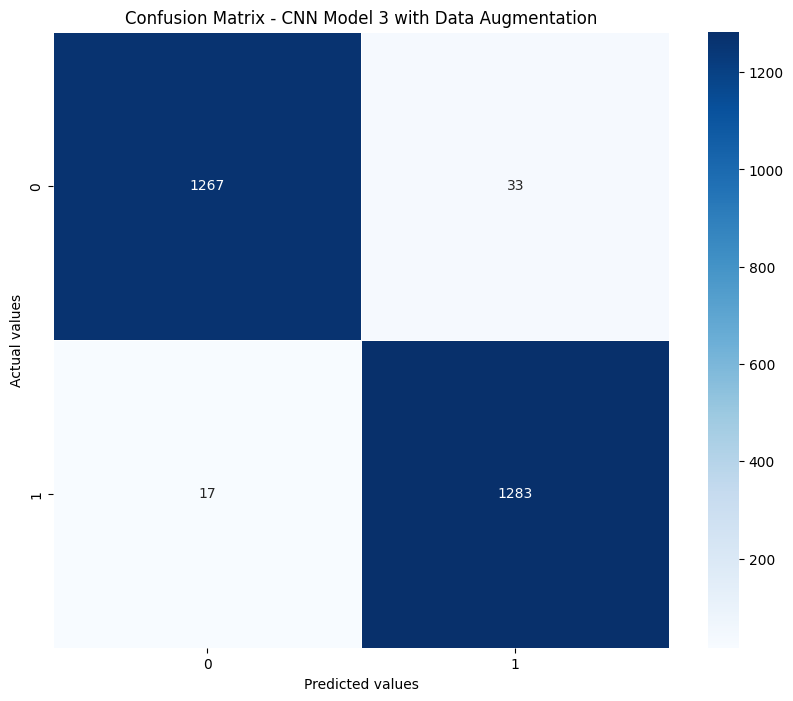

False Negatives (parasitized predicted as uninfected): 17
False Positives (uninfected predicted as parasitized): 33


In [21]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

test_pred = cnn_model_1gen.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - CNN Model 3 with Data Augmentation')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_gen = confusion_matrix[1][0].numpy()
FP_gen = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_gen}')
print(f'False Positives (uninfected predicted as parasitized): {FP_gen}')

In [22]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix
report_gen = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report for the Model 3 with Data Augmentation:")
print(report_gen)

Test Classification Report for the Model 3 with Data Augmentation:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1300
           1       0.97      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



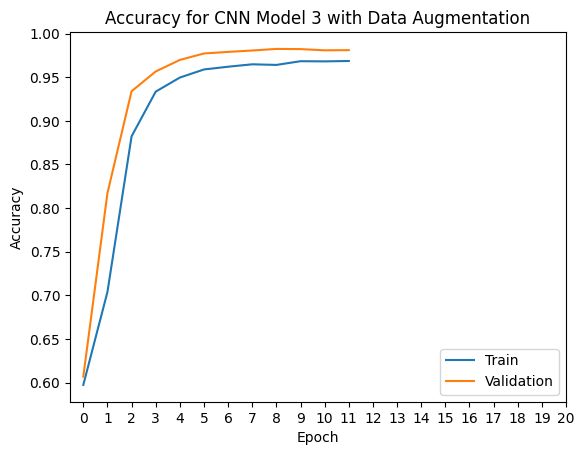

In [23]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history_gen.history['accuracy'])
plt.plot(history_gen.history['val_accuracy'])
plt.title('Accuracy for CNN Model 3 with Data Augmentation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()